This is the jupyter notebook that replicates the results for the real data based simulation studies in Section 4.2 and S4.2. 

The procedure and logic are similar for naive single-channel and multi-channel simulation studies, so I do not show them in detail. 

When I created this jupyter notebook, I used PyCharm and installed relevant packages under a virtual environment, denoted as ".venv".

It takes longer than running the same file in PyCharm directly. 

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first. I used "sys.argv[1]" to pass reader's own parent directory.

Please download the entire folder to your local desktop. I currently name it as ``BSM-Code-V2.''
1. Data Generation

Make sure you have installed the following python modules: (Version can be found in README.md)
* numpy, scipy, seaborn, matplotlib,
* tqdm
* jax, jaxlib, numpyro
* scikit-learn, 
* pyriemann, mne
* rpy2
* notebook

iteration 0


/Users/niubilitydiu/Desktop/BSM-Code-V2/Python/SIM_signal_parameter_multi_24.py:118: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig1, ax1 = plt.subplots(1, E, figsize=(12, 6))


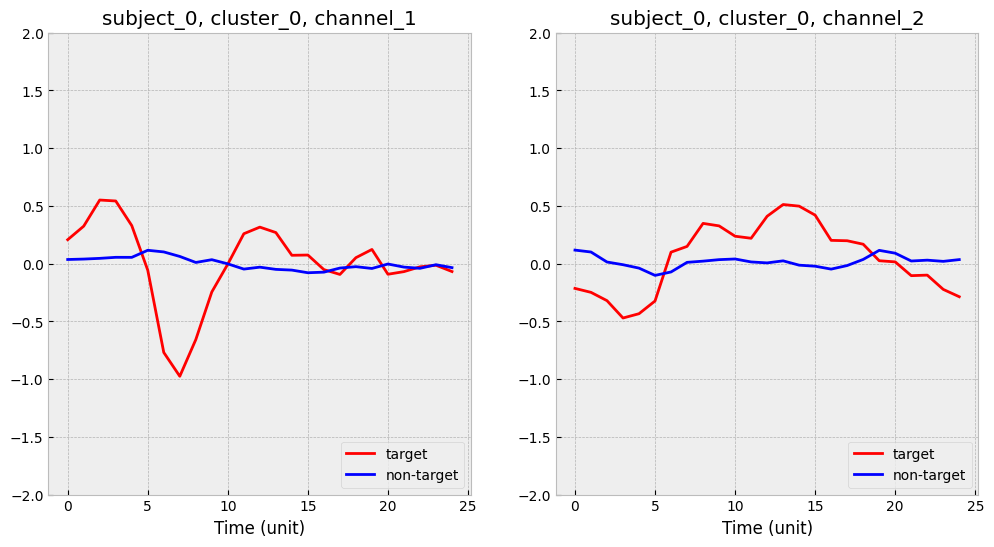

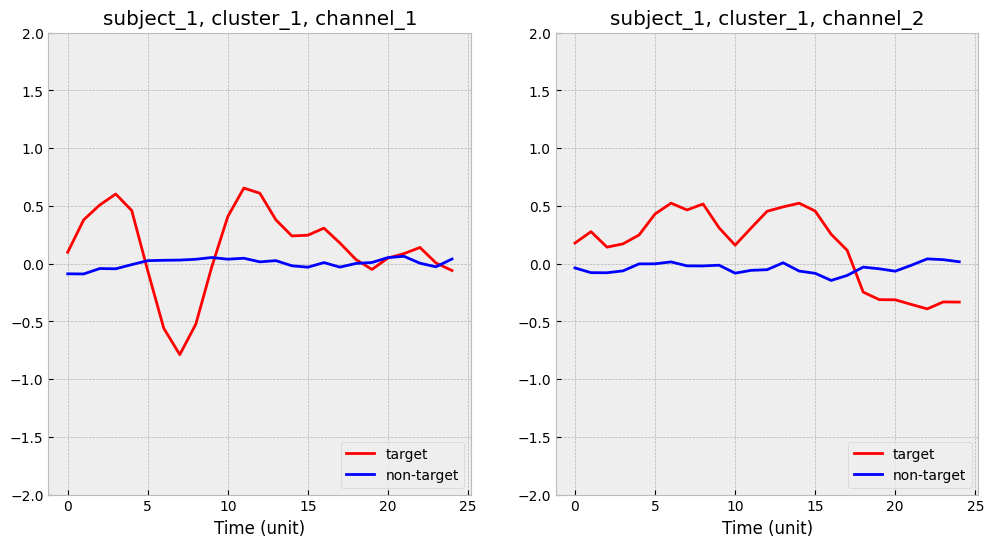

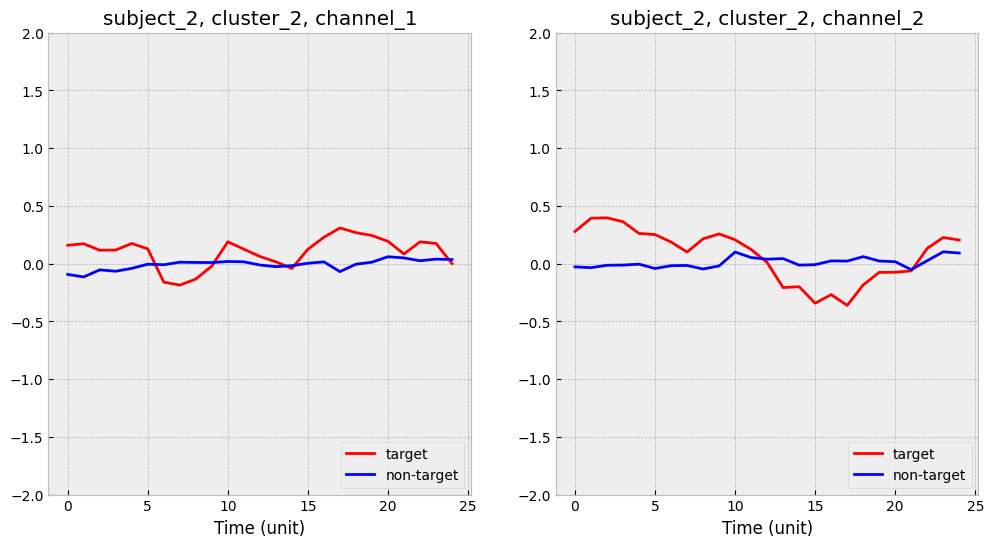

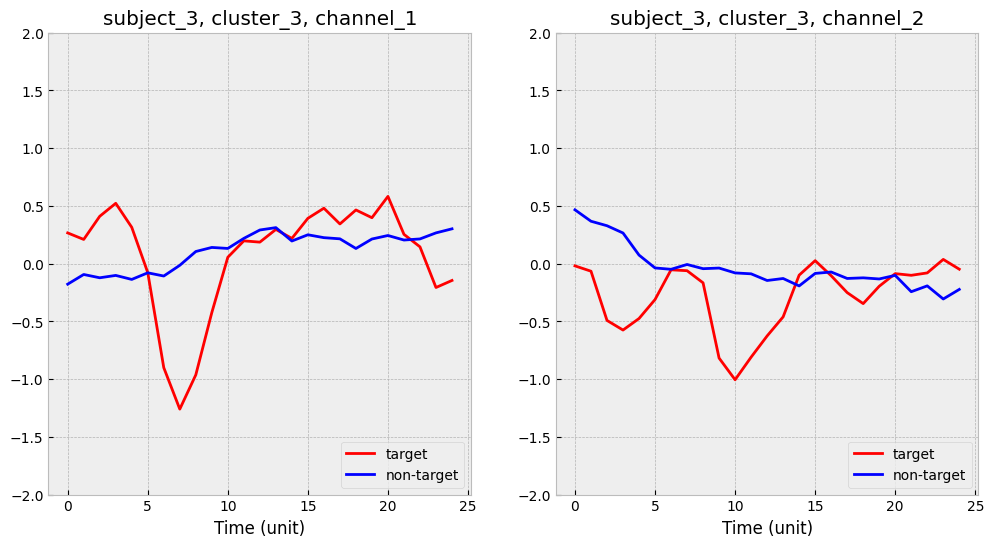

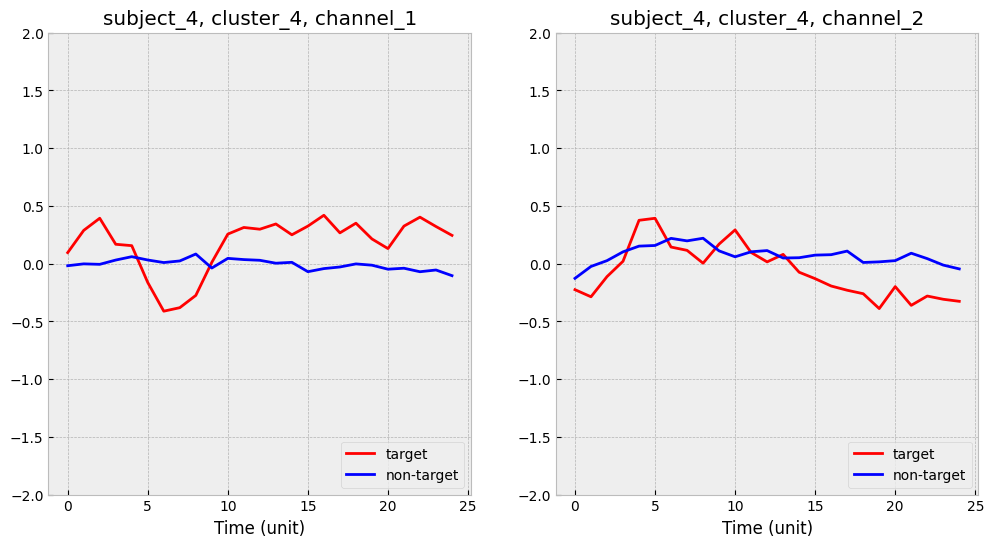

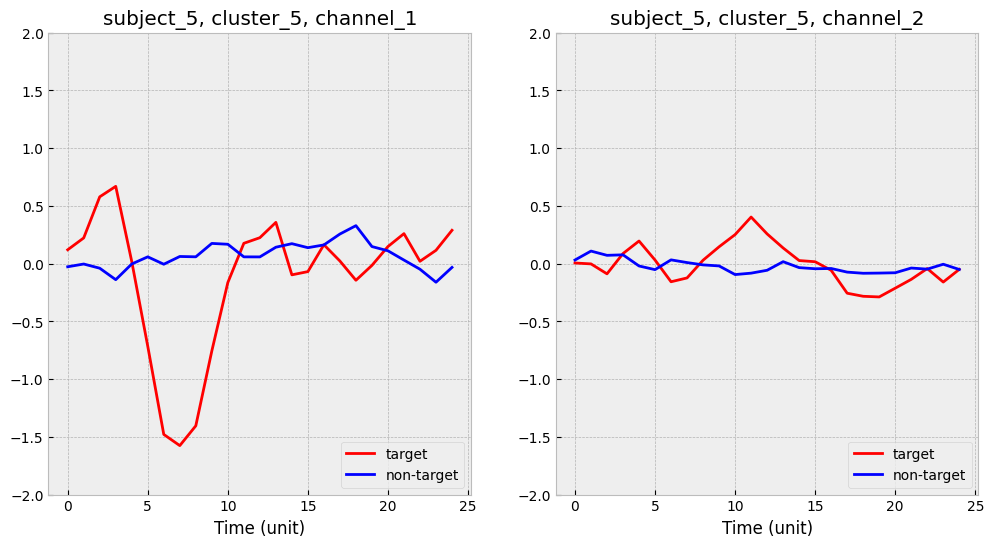

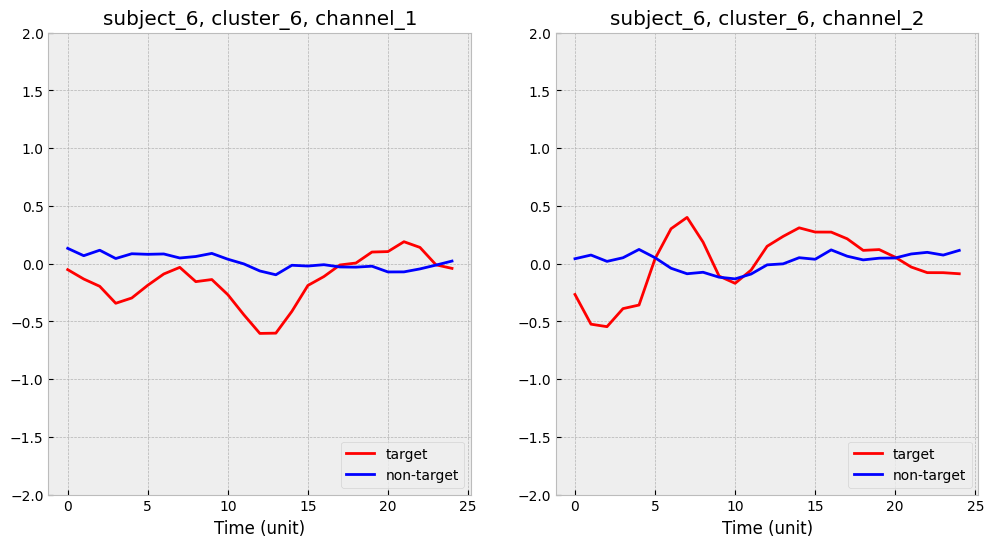

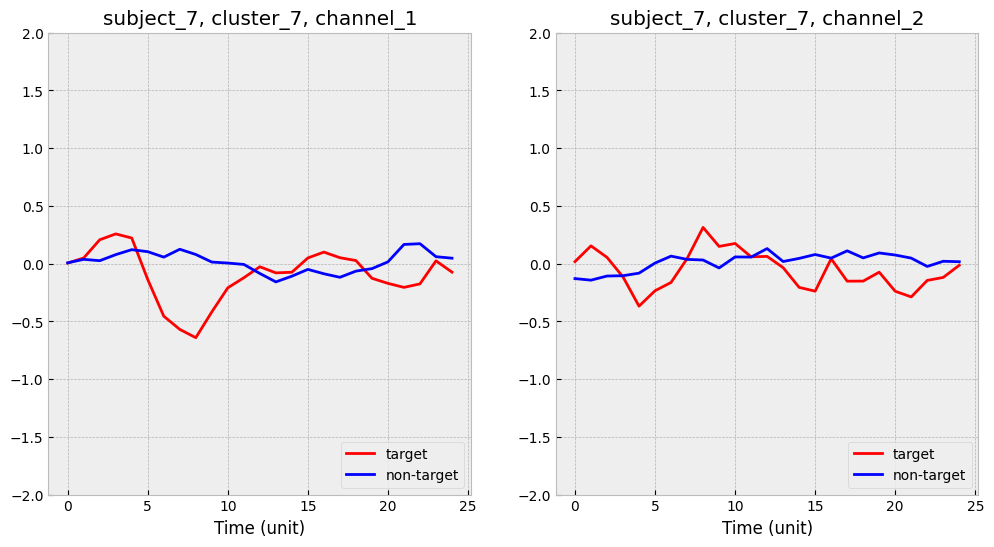

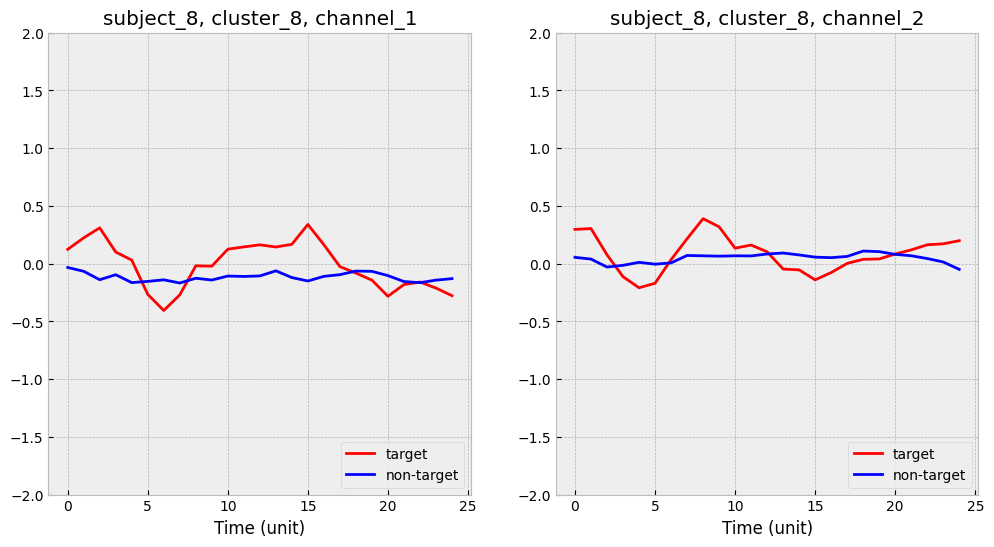

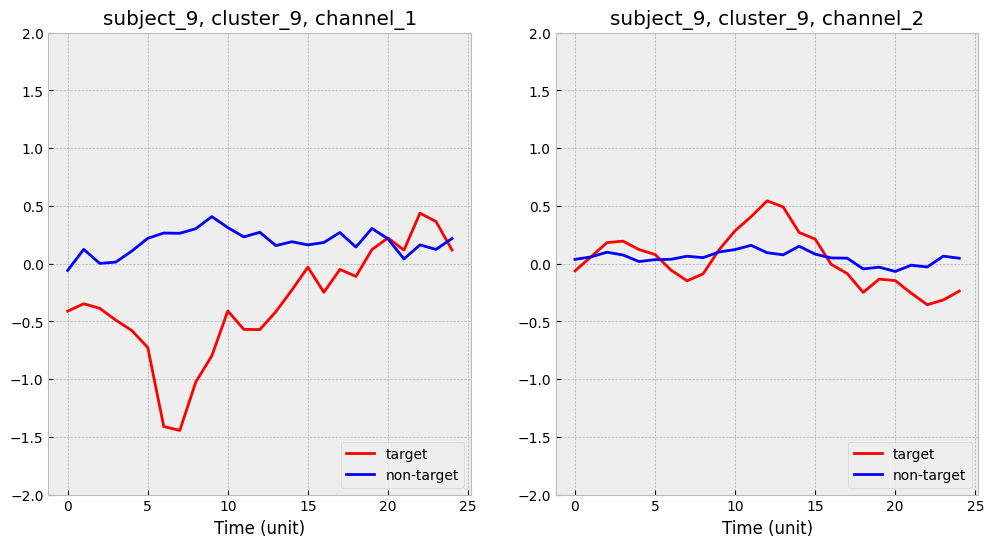

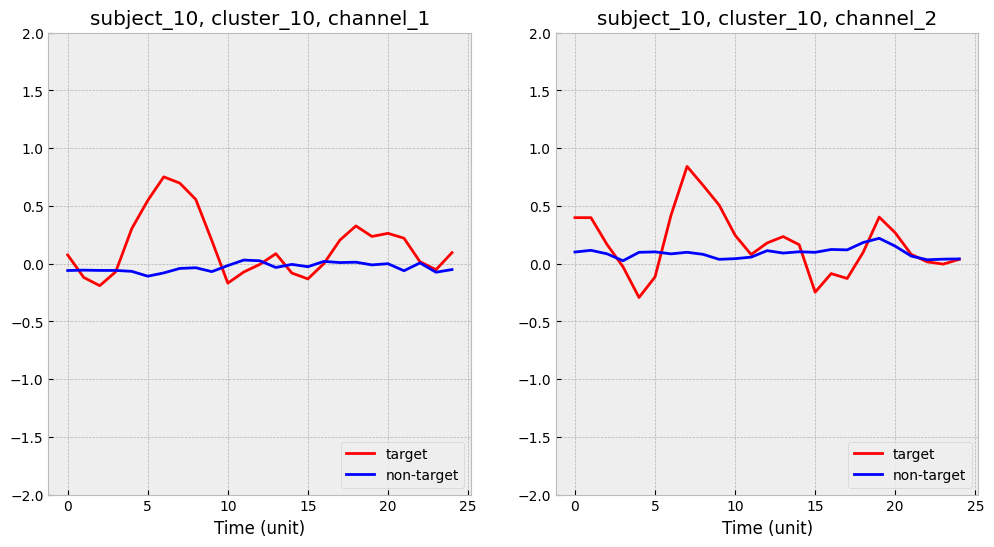

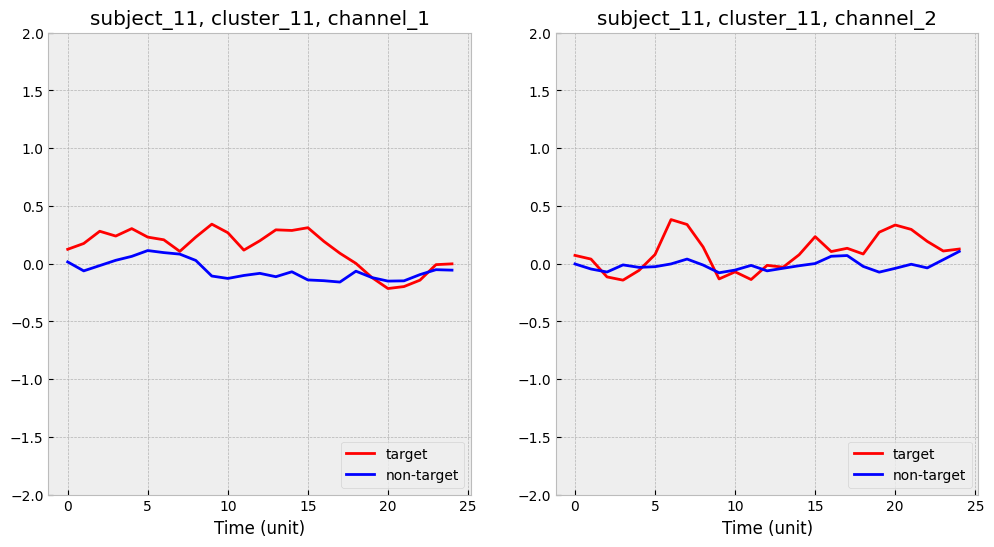

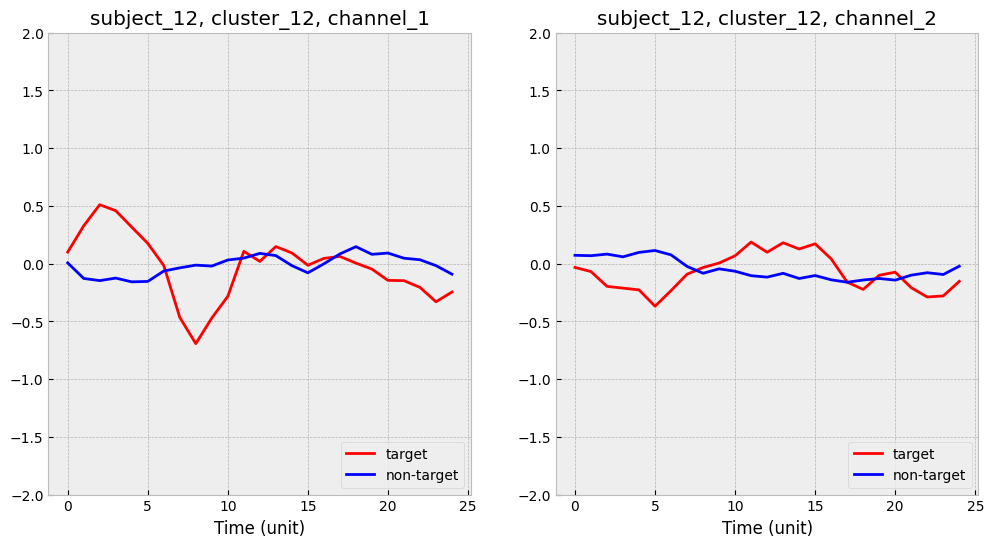

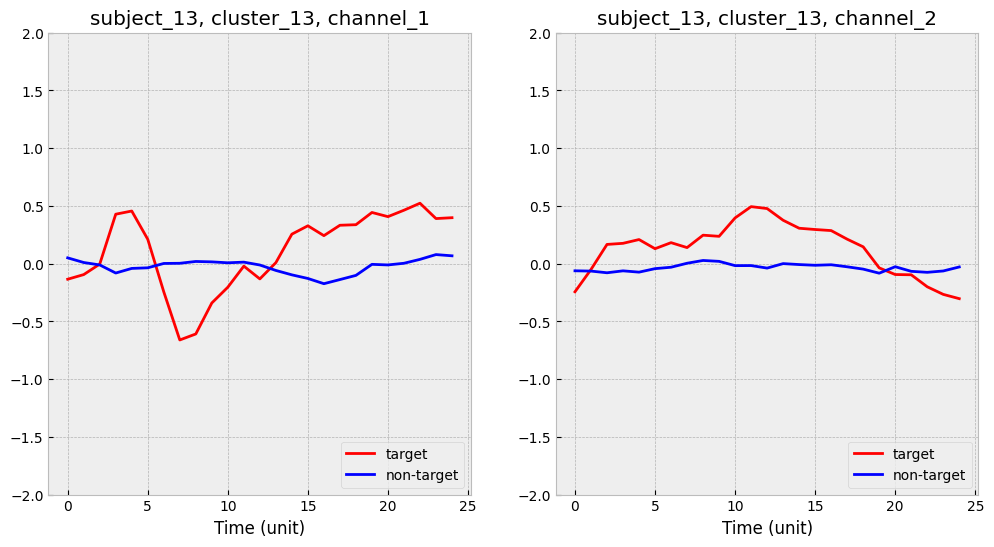

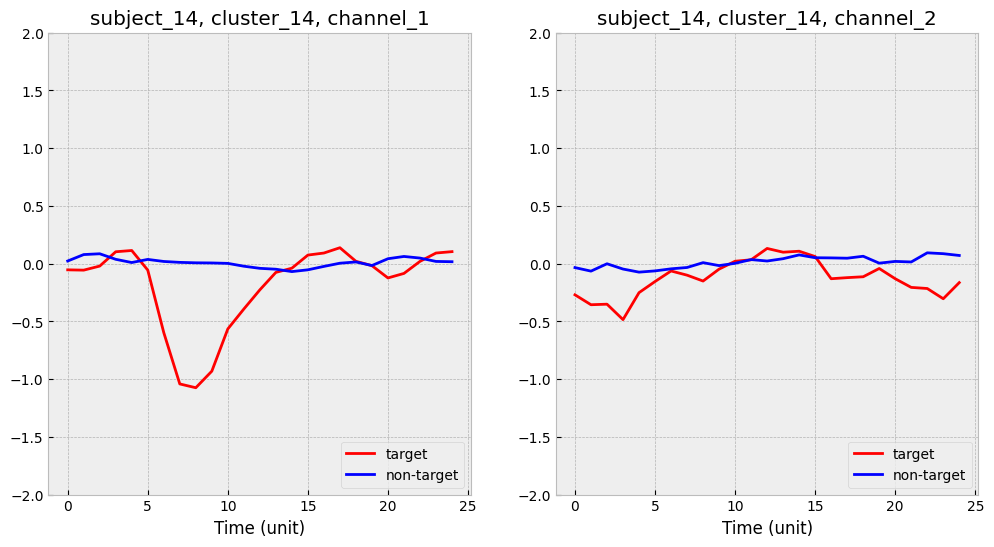

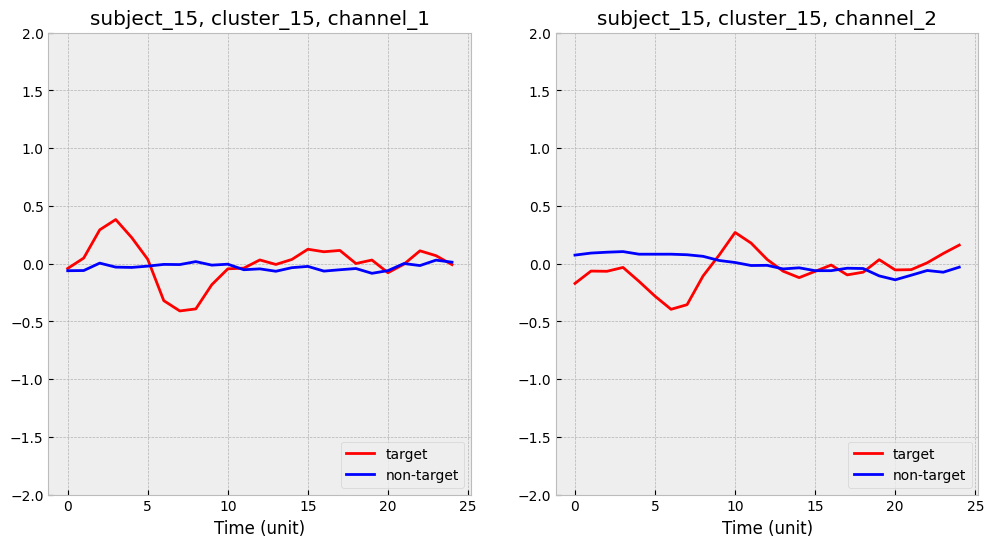

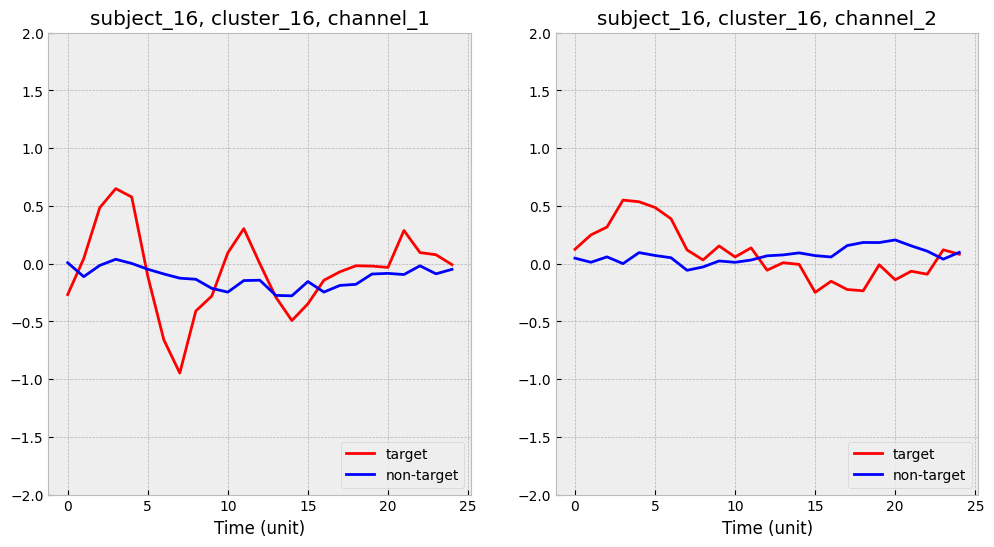

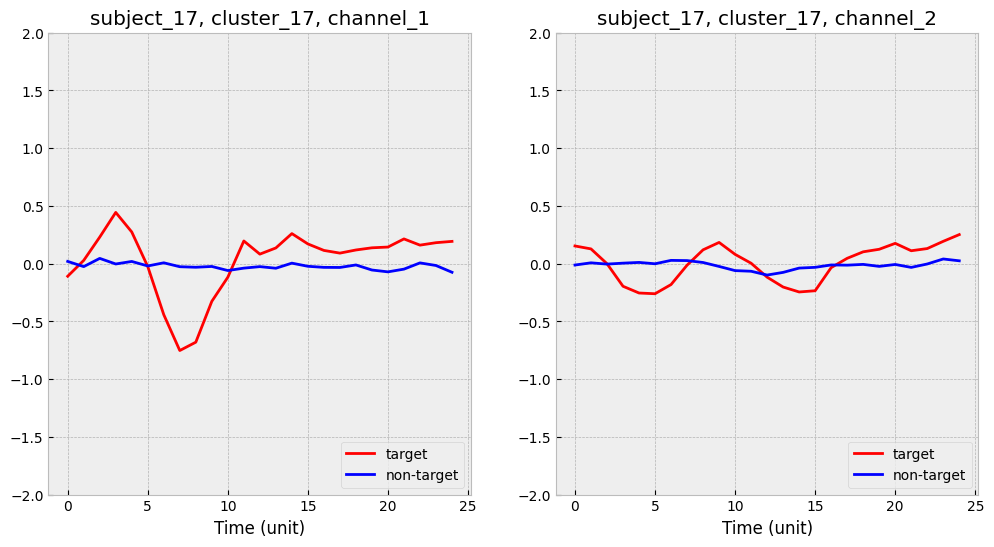

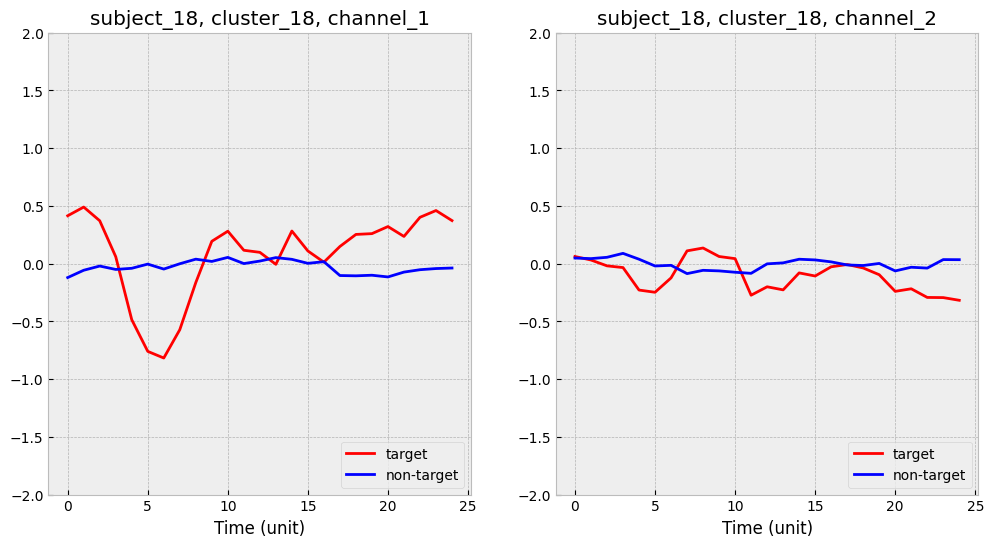

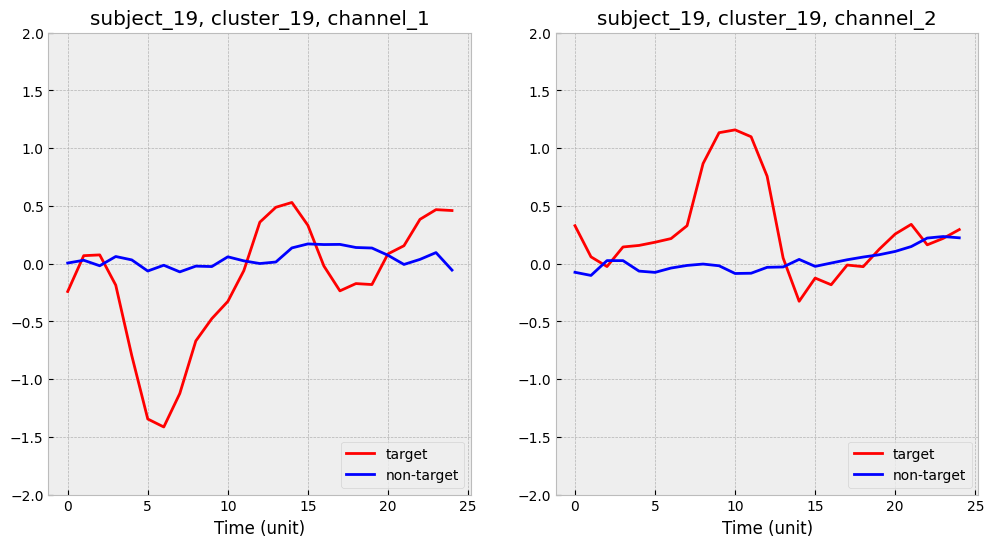

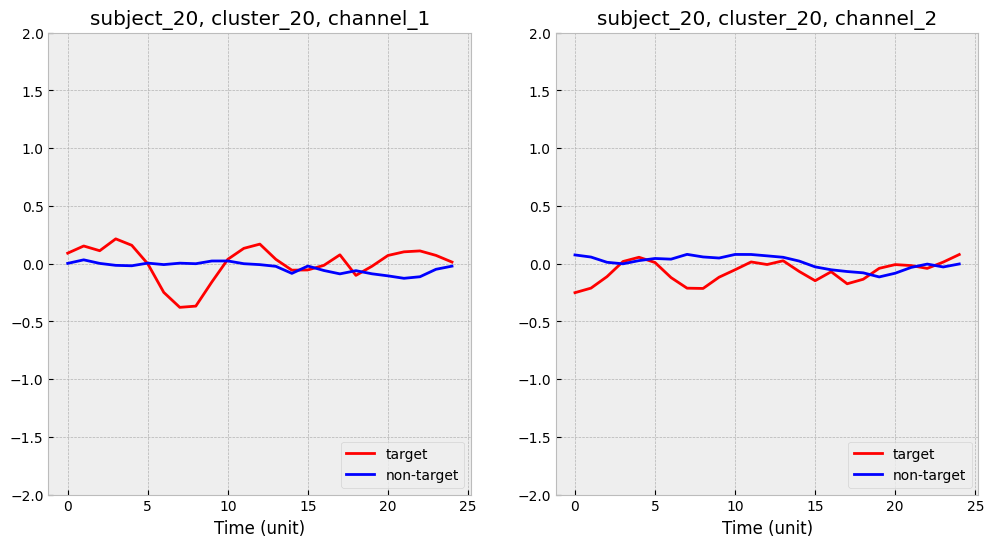

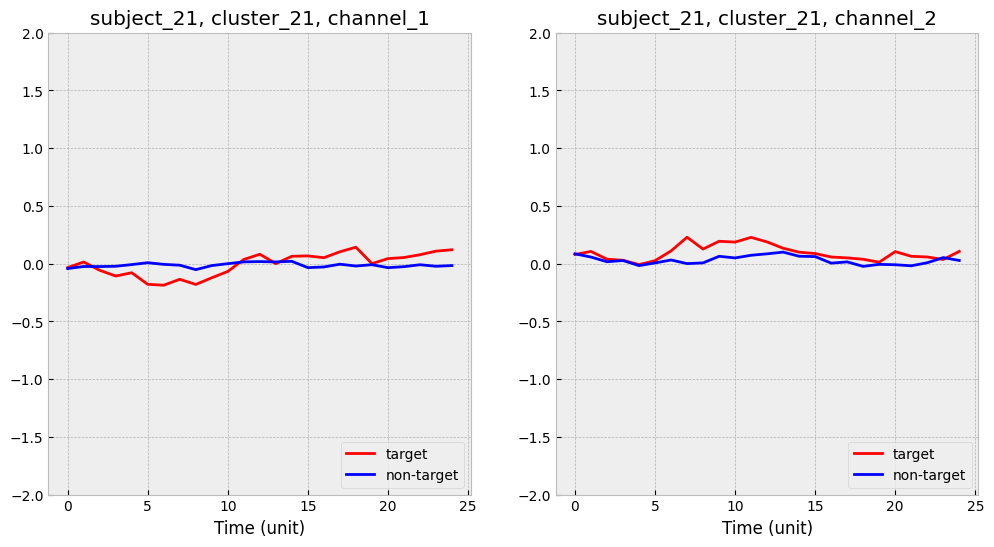

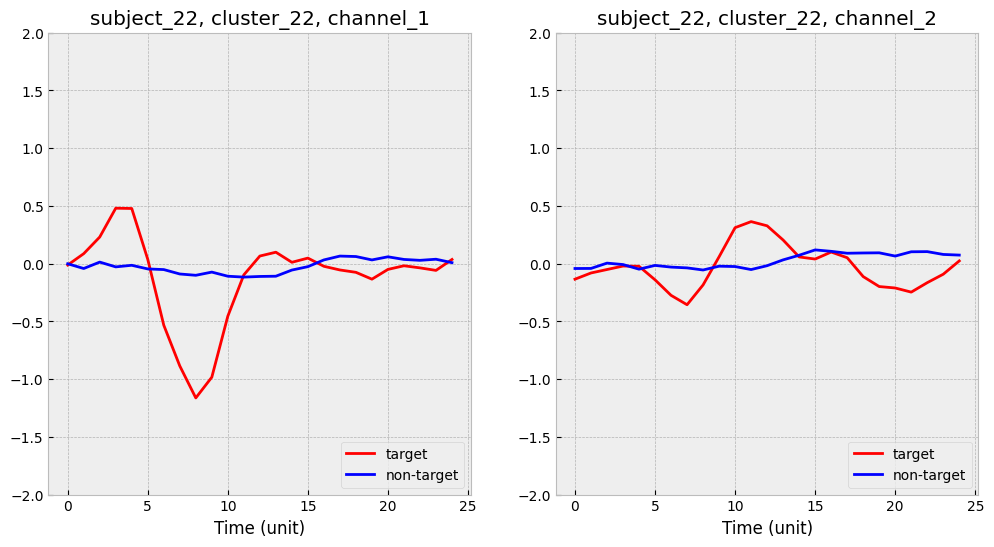

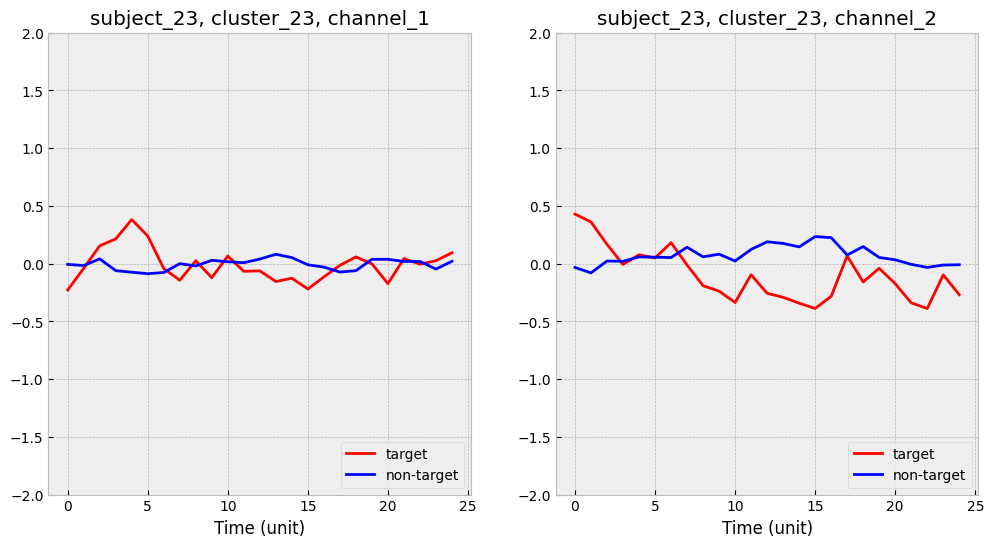

In [1]:
%run -i '~/Desktop/BSM-Code-V2/Python/SIM_signal_parameter_multi_24.py'

The above python file creates a real-data based simulated data under ./EEG_MATLAB_data/SIM_files/N_24_K_24_multi_xdawn_eeg/iter_0.

The resulting files include a training file "sim_dat.json" and a testing file "sim_dat_test.json". In the training file, we follow the setup of the real data analysis such that training data from 23 source participants are generated, in addition to the new participant.

2. Fitting BSM-Reference method:

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first. 

You need to vary the input parameter "seq_i" from 0 to 4 (They follow the python index). The current value seq_i=4 by default.

training sequence size = 5
9
12


sample: 100%|█| 2400/2400 [02:42<00:00, 14.74it/s, 15 steps of size 3.06e-01. ac



                       mean       std    median      5.0%     95.0%     n_eff     r_hat
alpha_ntar_0_0[0]      1.59      2.45      1.52     -2.00      6.00    835.30      1.00
alpha_ntar_0_0[1]      1.27      1.85      1.25     -2.07      3.73   1047.59      1.00
alpha_ntar_0_0[2]      0.35      1.25      0.37     -1.25      2.89   1576.37      1.00
alpha_ntar_0_0[3]     -0.53      0.93     -0.52     -1.98      0.94   1404.07      1.00
alpha_ntar_0_0[4]     -0.33      0.72     -0.31     -1.48      0.81   1681.73      1.00
alpha_ntar_0_0[5]      0.17      0.55      0.17     -0.66      1.08    759.85      1.01
alpha_ntar_0_0[6]     -0.04      0.52     -0.01     -0.83      0.83   1451.13      1.00
alpha_ntar_0_0[7]     -0.05      0.49     -0.04     -0.95      0.62    499.00      1.00
alpha_ntar_0_0[8]      0.31      0.37      0.34     -0.31      0.90    727.57      1.00
alpha_ntar_0_1[0]     -1.14      2.77     -1.05     -5.68      3.04   1358.84      1.00
alpha_ntar_0_1[1]      0.63    

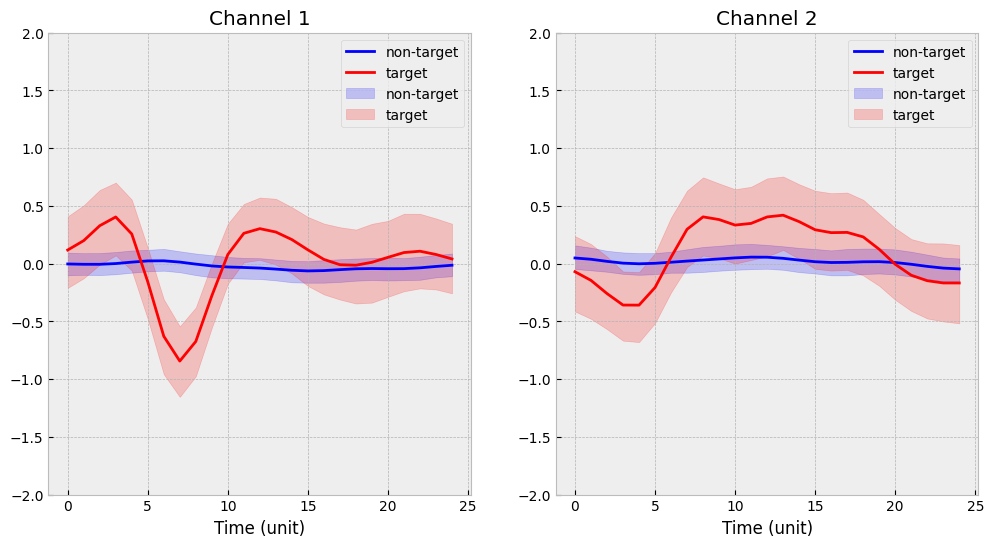

In [3]:
%run -i '~/Desktop/BSM-Code-V2/Python/numpyro_data_reference_signal_sim_multi_24.py' '/Users/niubilitydiu/Desktop/BSM-Code-V2'

The BSM-Reference method creates a new folder "reference_numpyro" and outputs three file per "seq_i", with "seq_i" ranging from 1 to 4:
* mcmc_sub_0_seq_size_(seq_i+1)_reference.mat
* plot_sub_0_seq_size_(seq_i+1)_reference.png
* summary_sub_0_seq_size_(seq_i+1)_reference.txt

When seq_i < 9, it takes about 3 minutes to finish the BSM-Reference modeling.

When seq_i=9, the file also triggers the modeling for 23 source participants. Unless the user plans to apply parallel computing, the above python file loops through 23 source participants, which takes 3 * 24 = 72 minutes to finish the BSM-Reference modeling. Three files per source participant are generated as follows, with "source_id" ranging from 1 to 23.
* mcmc_sub_(source_id)_seq_size_10_reference.mat
* plot_sub_(source_id)_seq_size_10_reference.png
* summary_sub_(source_id)_seq_size_10_reference.txt

To save readers' time, I have uploaded the remaining results to the folder.

3. Fitting BSM method:

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first.

You need to vary the input parameter "seq_i" from 0 to 4. The current value seq_i=4 by default.

The kernel hyperparameters are fixed as (0.3, 1.2) and (0.2, 1.2).

The number of chains is set to 2, with 5,000 burn-ins and 1,000 samples. The convergence is checked every 100 iterations.

In [ ]:
%run -i '~/Desktop/BSM-Code-V2/Python/gibbs_data_integration_signal_sim_multi_24.py' '/Users/niubilitydiu/Desktop/BSM-Code-V2'

The BSM method creates a new folder "borrow_gibbs" and outputs two files per "seq_i", with "seq_i" ranging from 1 to 4.
* mcmc_sub_0_seq_size_(seq_i+1)_cluster_log_lhd_diff_approx_2.0.mat
* plot_xdawn_seq_size_(seq_i+1)_2_chains_log_lhd_diff_approx_2.0.png

It takes about 1h to finish one chain. To facilitate the subsequent analysis, built-in MCMC objects for other training sequences have been stored in the same folder.

4. Fitting swLDA method:

Since my Jupyter notebook does not allow loading .m file directly. Please open MATLAB and identify the swLDA file
"~/Desktop/BSM-Code-V2/MATLAB/SIM_cluster_swLDA_MATLAB_multi_24.m"

The swLDA outputs one file per "seq_i", with "seq_i" ranging from 1 to 4.
* swLDA_output_seq_size_(seq_i+1).mat

It takes less than 1 minute to run swLDA locally per iteration. 

Since my jupyter notebook does not allow matlab integration and swLDA is not the primary focus of this work, an existing swLDA model objects have been stored.


In [33]:
# %matlab -nodisplay -nosplash -r "run('~/Desktop/BSM-Code-V2/MATLAB/SIM_cluster_swLDA_MATLAB_multi_24.m'); exit;"

UsageError: Line magic function `%matlab` not found.


5. Fitting MDWM method:

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first.

All the parameters are set to their default values.

In [34]:
%run -i "~/Desktop/BSM-Code-V2/Python/SIM_signal_predict_MDWM_multi_24.py" "/Users/niubilitydiu/Desktop/BSM-Code-V2"

Training sequence size = 2
Training sequence size = 3
Training sequence size = 4
Training sequence size = 5


The MDWM method creates a new folder "MDWM" and outputs training and testing prediction accuracy per "seq_i", with "seq_i" ranging from 1 to 4. The intermediate results are not saved.
* predict_sub_0_train_seq_size_(seq_i+1)_MDWM.json
* predict_sub_0_test_seq_size_(seq_i+1)_MDWM.json

It takes a couple of minutes to run MDWM.

6. Prediction 

All prediction methods should not take more than 5 minutes to complete.

a. BSM-Reference

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first.

The prediction codes will create training and testing prediction accuracy per "seq_i" under the folder "reference_numpyro", with "seq_i" ranging from 1 to 4.
* predict_sub_0_train_seq_size_(seq_i+1)_reference.json
* predict_sub_0_test_seq_size_(seq_i+1)_reference.json


In [2]:
# BSM-Reference
%run -i "~/Desktop/BSM-Code-V2/Python/SIM_signal_predict_reference_multi_24.py" "/Users/niubilitydiu/Desktop/BSM-Code-V2"

9
12
training sequence size: 2
training sequence size: 3
training sequence size: 4
training sequence size: 5


b. BSM: 

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first.

The prediction codes will create training and testing prediction accuracy per "seq_i" under the folder "reference_numpyro", with "seq_i" ranging from 1 to 4.
* predict_sub_0_train_seq_size_(seq_i+1)_cluster.json
* predict_sub_0_test_seq_size_(seq_i+1)_cluster.json


In [23]:
# BSM
%run -i "~/Desktop/BSM-Code-V2/Python/SIM_signal_predict_cluster_multi_24.py" "/Users/niubilitydiu/Desktop/BSM-Code-V2"

9
12
Training sequence size = 2
-0.5381671137111281, 0.2130297812408825, 0.6220343727389567
Training sequence size = 3
-0.4335792519433295, 0.22524550502137466, 0.6377778077191795
Training sequence size = 4
-0.4577604455832327, 0.2421969861976767, 0.6800126336245675
Training sequence size = 5
-0.5575676038359637, 0.30929793362881147, 0.7784838082053739


c. BSM-Mixture

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first.

We follow the algorithm proposed in Section 3.3 and adopt a delta_Z of 0.1.

The prediction codes will create a new folder "mixture_gibbs" and output training and testing prediction accuracy per "seq_i", with "seq_i" ranging from 1 to 4.

* predict_sub_0_train_seq_size_(seq_i+1)_mixture.json
* predict_sub_0_test_seq_size_(seq_i+1)_mixture.json


In [25]:
# BSM-Mixture
%run -i "~/Desktop/BSM-Code-V2/Python/SIM_signal_predict_mixture_multi_24.py" "/Users/niubilitydiu/Desktop/BSM-Code-V2"

9
12
training sequence size: 2
At least one source participant is selected by threshold 0.1. Use BSM-Cluster for prediction.
-0.5381671137111281, 0.2130297812408825, 0.6220343727389567
training sequence size: 3
At least one source participant is selected by threshold 0.1. Use BSM-Cluster for prediction.
-0.4335792519433295, 0.22524550502137466, 0.6377778077191795
training sequence size: 4
At least one source participant is selected by threshold 0.1. Use BSM-Cluster for prediction.
-0.4577604455832327, 0.2421969861976767, 0.6800126336245675
training sequence size: 5
At least one source participant is selected by threshold 0.1. Use BSM-Cluster for prediction.
-0.5575676038359637, 0.30929793362881147, 0.7784838082053739


d. swLDA (Baseline Reference)

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first.

The prediction codes will create training and testing prediction accuracy per "seq_i" under the folder "reference_numpyro", with "seq_i" ranging from 1 to 4.
* predict_sub_0_train_seq_size_(seq_i+1)_swLDA.json
* predict_sub_0_test_seq_size_(seq_i+1)_swLDA.json


In [26]:
# swLDA
%run -i "~/Desktop/BSM-Code-V2/Python/SIM_signal_predict_swLDA_multi_24.py" "/Users/niubilitydiu/Desktop/BSM-Code-V2"

Training sequence size: 2
0.4484834382399521 -0.041381009830476864 0.36984575741510917
0.31463916999450786 -0.013107189615634616 0.30186048508309404
Training sequence size: 3
0.29837174859520693 -0.029895664193683388 0.3024948124824371
0.2881225058528249 -0.012002234899390583 0.28885089298932104
Training sequence size: 4
0.32599904222538756 -0.014312939637587178 0.30786023384382993
0.28261253640426365 -0.01131520480339508 0.2858450436305054
Training sequence size: 5
0.3208301126463627 -0.01250599619939178 0.304609043084657
0.2997529435249479 -0.011143767293871279 0.29397314755845605


e. MDWM

See section 5.

7. Inferences and Visualization of Prediction Accuracy

For each simulation replication, parameter estimates and matching results, i.e., Prob(Z_n=1), are summarized as plots and can be found under the folder "./iter_X/borrow_gibbs".
* plot_xdawn_seq_size_(seq_i+1)_2_chains_log_lhd_diff_approx_2.0.png

For aggregated matching result (Figure S6) and prediction accuracy (Figure 4), R is applied to produce the plots. 

Prediction accuracy and Z values across 100 replications have been pre-stored under "prediction_summary" folder.

Install rpy2 module first!

In [27]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/niubilitydiu/Desktop/BSM-Code-V2/Python/venv/lib/python3.8/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace '_R_BaseEnv'")
Trying to import in ABI mode.
/Users/niubilitydiu/Desktop/BSM-Code-V2/Python/venv/lib/python3.8/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/0f/kvhhlqxj3hj9fvbp7hb3xx280000gn/T//RtmpPAVivw", R: "/var/folders/0f/kvhhlqxj3hj9fvbp7hb3xx280000gn/T//RtmpfSbx7O"
  warnings.warn(


Make sure you have installed the following R packages (Versions can be found in README.md):
* R.matlab
* R.utils
* ggplot2
* gridExtra

You need to change the directory "/Users/niubilitydiu/Desktop/BSM-Code-V2" to your own first.

[1] "Training sequence size = 2"
[1] "Training sequence size = 3"
[1] "Training sequence size = 4"
[1] "Training sequence size = 5"


In addition: Warning message:
In dir.create(file.path(parent_sim_data_dir, "prediction_summary")) :
  '/Users/niubilitydiu/Desktop/BSM-Code-V2/EEG_MATLAB_data/SIM_files/N_24_K_24_multi_xdawn_eeg/prediction_summary' already exists


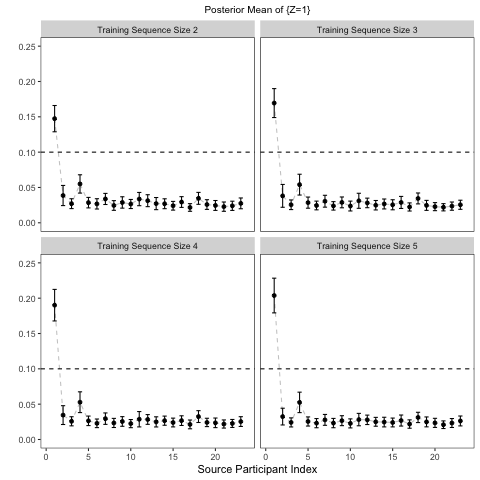

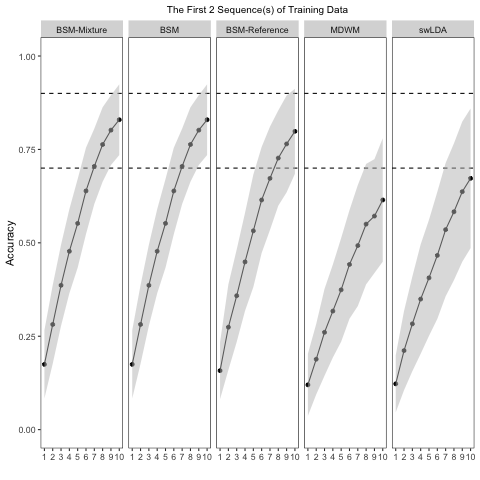

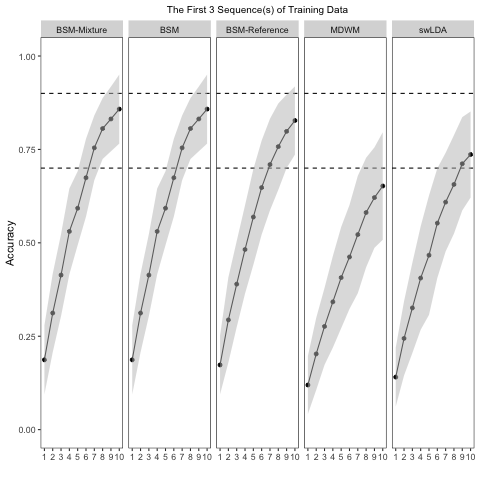

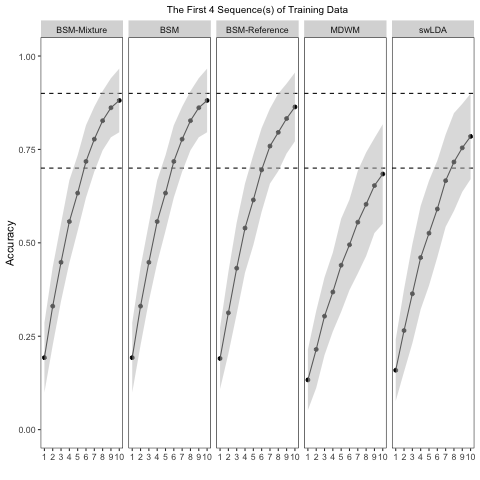

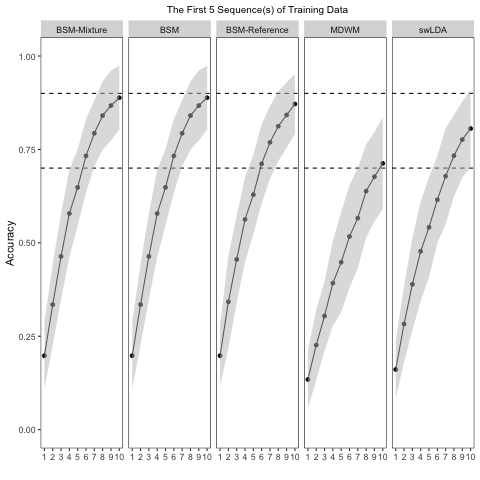

In [32]:
%%R
source("~/Desktop/BSM-Code-V2/R/sim_summary_3way_multi_24.R")
parent_dir = '/Users/niubilitydiu/Desktop/BSM-Code-V2'

Plots and csv files are generated and saved under the folder "prediction_summary".
* plot_p_bsm_cluster_z_seq_train_size_2-5_iteration_100.png (Figure S6)
* plot_predict_test_fix_seq_train_size_(seq_i+1)_iteration_100.png (Figure 4)
* test_xx_backward_seq_size.csv
* test_xx_forward_seq_size.csv